# 04 — Santa Ynez River

Produces:
- **Figure 19**: Combined map (Panel A: stream order map with restored + NWIS sites) and timeline (Panel B: sites per year by stream order)
- **Table 7**: NWIS stream sites per stream order with start/end years
- **Table 8**: NWIS vs. restored stream sites per stream order
- **Table 9**: Restored sites per decade and stream order

Requires:
- `data/analysis/processed_metadata.parquet` (output of `00_data_prep.ipynb`)
- `data/analysis/spatial/santaynezhuc8/santaynez.shp` — HUC8 watershed boundary
- `data/analysis/spatial/rivers/StreamsandRivers_Clip.shp` — river network with stream order
- `data/analysis/spatial/lakes/chap2map.gdb` — National Wetlands Inventory lakes (GDB)
- `data/analysis/nwis_sites/sb_streamflow_sites.csv` — pre-downloaded NWIS stream sites (SB county)
- `data/analysis/nwis_sites/stream_proximity_results.csv` — pre-computed stream order proximity for restored sites

In [1]:
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from collections import defaultdict
from pathlib import Path
import sys
sys.path.insert(0, str(Path('.')))
from water_palette import get_color_for

root         = Path('../..')
parquet_path = root / 'data/analysis/processed_metadata.parquet'
spatial_path = root / 'data/analysis/spatial'
nwis_path    = root / 'data/analysis/nwis_sites'
figures_path = root / 'manuscript/figures'
figures_path.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(parquet_path)
print(f'Loaded {len(df):,} rows')

Loaded 109,440 rows


## Load spatial reference layers

In [2]:
watershed  = gpd.read_file(spatial_path / 'santaynezhuc8/santaynez.shp').to_crs('EPSG:4326')

# Rivers and lakes both live in chap2map.gdb.
# The GDB version of StreamsandRivers_Clip has StreamOrderEdit (manually edited, values 1–5).
# The standalone .shp export has StreamOrde = 1 for all features — do not use it.
try:
    import fiona
    layers = fiona.listlayers(str(spatial_path / 'lakes/chap2map.gdb'))
    print('GDB layers:', layers)
    rivers = gpd.read_file(spatial_path / 'lakes/chap2map.gdb', layer='StreamsandRivers_Clip').to_crs('EPSG:4326')
    print(f'Loaded {len(rivers)} river features from GDB')
    lake_layer = [l for l in layers if 'lake' in l.lower() or 'wetland' in l.lower()][0]
    lakes = gpd.read_file(spatial_path / 'lakes/chap2map.gdb', layer=lake_layer).to_crs('EPSG:4326')
    print(f'Loaded lakes layer: {lake_layer}')
except Exception as e:
    print(f'Could not load GDB: {e}')
    rivers = None
    lakes = None

# Optional SB county basemap
sb_county = None
try:
    sb_county = gpd.read_file(spatial_path / 'sb_county_shapefile/sb_county_shp.shp').to_crs('EPSG:4326')
    print('Loaded SB county shapefile')
except Exception as e:
    print(f'Could not load SB county: {e}')

order_cols = [c for c in (rivers.columns if rivers is not None else []) if 'order' in c.lower() or 'Order' in c]
print('Order-related columns:', order_cols)

GDB layers: ['StreamsandRivers_Clip', 'LakesNationalWetlandsInventory_ExportFeatures']
Loaded 1653 river features from GDB
Loaded lakes layer: LakesNationalWetlandsInventory_ExportFeatures
Loaded SB county shapefile
Order-related columns: ['StreamOrderEdit']


/Users/annaboser/Documents/GitHub/usgs_extract/.venv/lib/python3.9/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


## Filter restored stream discharge sites to Santa Ynez watershed

In [3]:
df_sd = df[
    (df['water_type_clean'] == 'Stream Discharge') &
    df['lat_combined'].notna() &
    df['lon_combined'].notna()
].copy()

gdf_sd = gpd.GeoDataFrame(
    df_sd,
    geometry=gpd.points_from_xy(df_sd['lon_combined'], df_sd['lat_combined']),
    crs='EPSG:4326'
)

# Spatial filter to watershed
gdf_sy = gpd.sjoin(gdf_sd, watershed[['geometry']], how='inner', predicate='within')

# Also text-filter: check location column mentions Santa Ynez
if 'location' in df.columns:
    sy_text = df_sd[
        df_sd['location'].str.contains('santa ynez|ynez', case=False, na=False)
    ]
    sy_text_gdf = gpd.GeoDataFrame(
        sy_text,
        geometry=gpd.points_from_xy(sy_text['lon_combined'], sy_text['lat_combined']),
        crs='EPSG:4326'
    )
    # Union: spatial + text filter
    gdf_sy = pd.concat([gdf_sy, sy_text_gdf]).drop_duplicates()

print(f'{len(gdf_sy):,} restored stream discharge sites in Santa Ynez watershed')

1,575 restored stream discharge sites in Santa Ynez watershed


## Load pre-computed stream proximity and NWIS sites

`stream_proximity_results.csv` contains restored stream discharge sites with their closest stream order pre-computed. `sb_streamflow_sites.csv` contains the 21 NWIS stream sites for SB county; we filter these to the Santa Ynez watershed spatially.

In [4]:
streamprox = pd.read_csv(nwis_path / 'stream_proximity_results.csv')
print(f'Stream proximity rows: {len(streamprox):,}')
print(streamprox.columns.tolist())
print(streamprox.head(3))

# gdf_sy_order: restored sites with stream order assigned
gdf_sy_order = gpd.GeoDataFrame(
    streamprox,
    geometry=gpd.points_from_xy(streamprox['longitude'], streamprox['latitude']),
    crs='EPSG:4326'
)
gdf_sy_order = gdf_sy_order.rename(columns={'closest_stream_order': 'stream_order'})

Stream proximity rows: 714
['site_index', 'site_id', 'station_name', 'data_type', 'start_year', 'end_year', 'year_start', 'year_end', 'decade_start', 'decade_end', 'decade', 'closest_stream_order', 'distance_to_stream_km', 'longitude', 'latitude']
   site_index  site_id station_name   data_type  start_year  end_year  \
0           0      NaN      Unknown  Historical      1920.0    1966.0   
1           1      NaN      Unknown  Historical      1968.0    1969.0   
2           3      NaN      Unknown  Historical      1953.0    1954.0   

   year_start  year_end  decade_start  decade_end  decade  \
0      1920.0    1966.0        1920.0      1960.0  1920.0   
1      1968.0    1969.0        1960.0      1960.0  1960.0   
2      1953.0    1954.0        1950.0      1950.0  1950.0   

   closest_stream_order  distance_to_stream_km   longitude   latitude  
0                     5               0.112087 -119.686000  34.527000  
1                     5               0.009286 -119.863889  34.543611 

## NWIS stream sites in the Santa Ynez watershed

Loads pre-downloaded NWIS stream sites from `data/analysis/nwis_sites/sb_streamflow_sites.csv` if it exists, then filters spatially to the Santa Ynez watershed. If the file doesn't exist, queries the NWIS API and saves it.

In [5]:
stream_path = nwis_path / 'sb_streamflow_sites.csv'

if stream_path.exists():
    nwis_stream = pd.read_csv(stream_path)
    print(f'Loaded {len(nwis_stream):,} NWIS stream sites from file')
else:
    from dataretrieval import nwis
    nwis_stream, _ = nwis.what_sites(
        stateCd='CA', countyCd='06083', siteType='ST'
    )
    nwis_stream = nwis_stream.rename(columns={'dec_lat_va': 'latitude', 'dec_long_va': 'longitude',
                                               'station_nm': 'station_name'})
    if 'begin_date' in nwis_stream.columns:
        nwis_stream['start_year'] = pd.to_datetime(nwis_stream['begin_date'], errors='coerce').dt.year
    if 'end_date' in nwis_stream.columns:
        nwis_stream['end_year'] = pd.to_datetime(nwis_stream['end_date'], errors='coerce').dt.year
    stream_path.parent.mkdir(parents=True, exist_ok=True)
    nwis_stream.to_csv(stream_path, index=False)
    print(f'Downloaded and saved {len(nwis_stream):,} NWIS stream sites')

nwis_stream_geo = gpd.GeoDataFrame(
    nwis_stream,
    geometry=gpd.points_from_xy(nwis_stream['longitude'], nwis_stream['latitude']),
    crs='EPSG:4326'
)
nwis_sy = gpd.sjoin(nwis_stream_geo, watershed[['geometry']], how='inner', predicate='within')
print(f'NWIS stream sites within Santa Ynez watershed: {len(nwis_sy):,}')

Loaded 21 NWIS stream sites from file
NWIS stream sites within Santa Ynez watershed: 7


## Table 7 — NWIS stream sites per stream order

In [6]:
order_col = None
for candidate in ['StreamOrderEdit', 'StreamOrde', 'Strahler', 'stream_order', 'ORDER', 'order']:
    if rivers is not None and candidate in rivers.columns:
        order_col = candidate
        break
print('Stream order column:', order_col)

# Drop index_right from prior sjoin before doing sjoin_nearest
nwis_sy_clean = nwis_sy.drop(columns=['index_right'], errors='ignore')
nwis_sy_proj  = nwis_sy_clean.to_crs('EPSG:3310')
rivers_proj   = rivers.to_crs('EPSG:3310')

if order_col:
    nwis_sy_order = gpd.sjoin_nearest(nwis_sy_proj, rivers_proj[[order_col, 'geometry']], how='left')
    nwis_sy_order = nwis_sy_order.rename(columns={order_col: 'stream_order'})
    table7 = (
        nwis_sy_order.groupby('stream_order')
        .agg(n_sites=('site_no', 'count'),
             year_start=('start_year', 'min'),
             year_end=('end_year', 'max'))
        .reset_index()
    )
    print('\nTable 7: NWIS stream sites per stream order')
    print(table7.to_string(index=False))
else:
    print('Stream order column not found in rivers — check rivers.columns')

Stream order column: StreamOrderEdit

Table 7: NWIS stream sites per stream order
 stream_order  n_sites  year_start  year_end
            2        1        1971      1978
            4        2        1952      1978
            5        4        1952      1979


## Table 8 — NWIS vs restored sites per stream order

In [7]:
restored_by_order = (
    gdf_sy_order.groupby('stream_order').size().reset_index(name='n_restored')
)
nwis_by_order = (
    table7[['stream_order', 'n_sites']].rename(columns={'n_sites': 'n_nwis'})
    if 'table7' in globals() else pd.DataFrame(columns=['stream_order', 'n_nwis'])
)
table8 = pd.merge(nwis_by_order, restored_by_order, on='stream_order', how='outer').fillna(0).sort_values('stream_order')
print('Table 8: NWIS vs restored stream sites per stream order')
print(table8.to_string(index=False))

Table 8: NWIS vs restored stream sites per stream order
 stream_order  n_nwis  n_restored
            1     0.0          99
            2     1.0         129
            3     0.0          44
            4     2.0          22
            5     4.0         420


## Table 9 — Restored sites per decade and stream order

In [8]:
table9 = (
    gdf_sy_order.groupby(['decade_start', 'stream_order'])
    .size()
    .reset_index(name='n_sites')
    .pivot(index='decade_start', columns='stream_order', values='n_sites')
    .fillna(0).astype(int)
)
print('Table 9: Restored stream sites per decade and stream order')
print(table9.to_string())

Table 9: Restored stream sites per decade and stream order
stream_order   1   2   3  4    5
decade_start                    
1900.0         5  14   0  1   35
1910.0         3  15   0  0   10
1920.0        14  14   2  4   59
1930.0         1   7  18  2    8
1940.0         8  21   4  5  113
1950.0        20  31   3  6   92
1960.0        13  10   5  3   63
1970.0         3   1   1  0   24


## Figure 19 — Stream order map + timeline

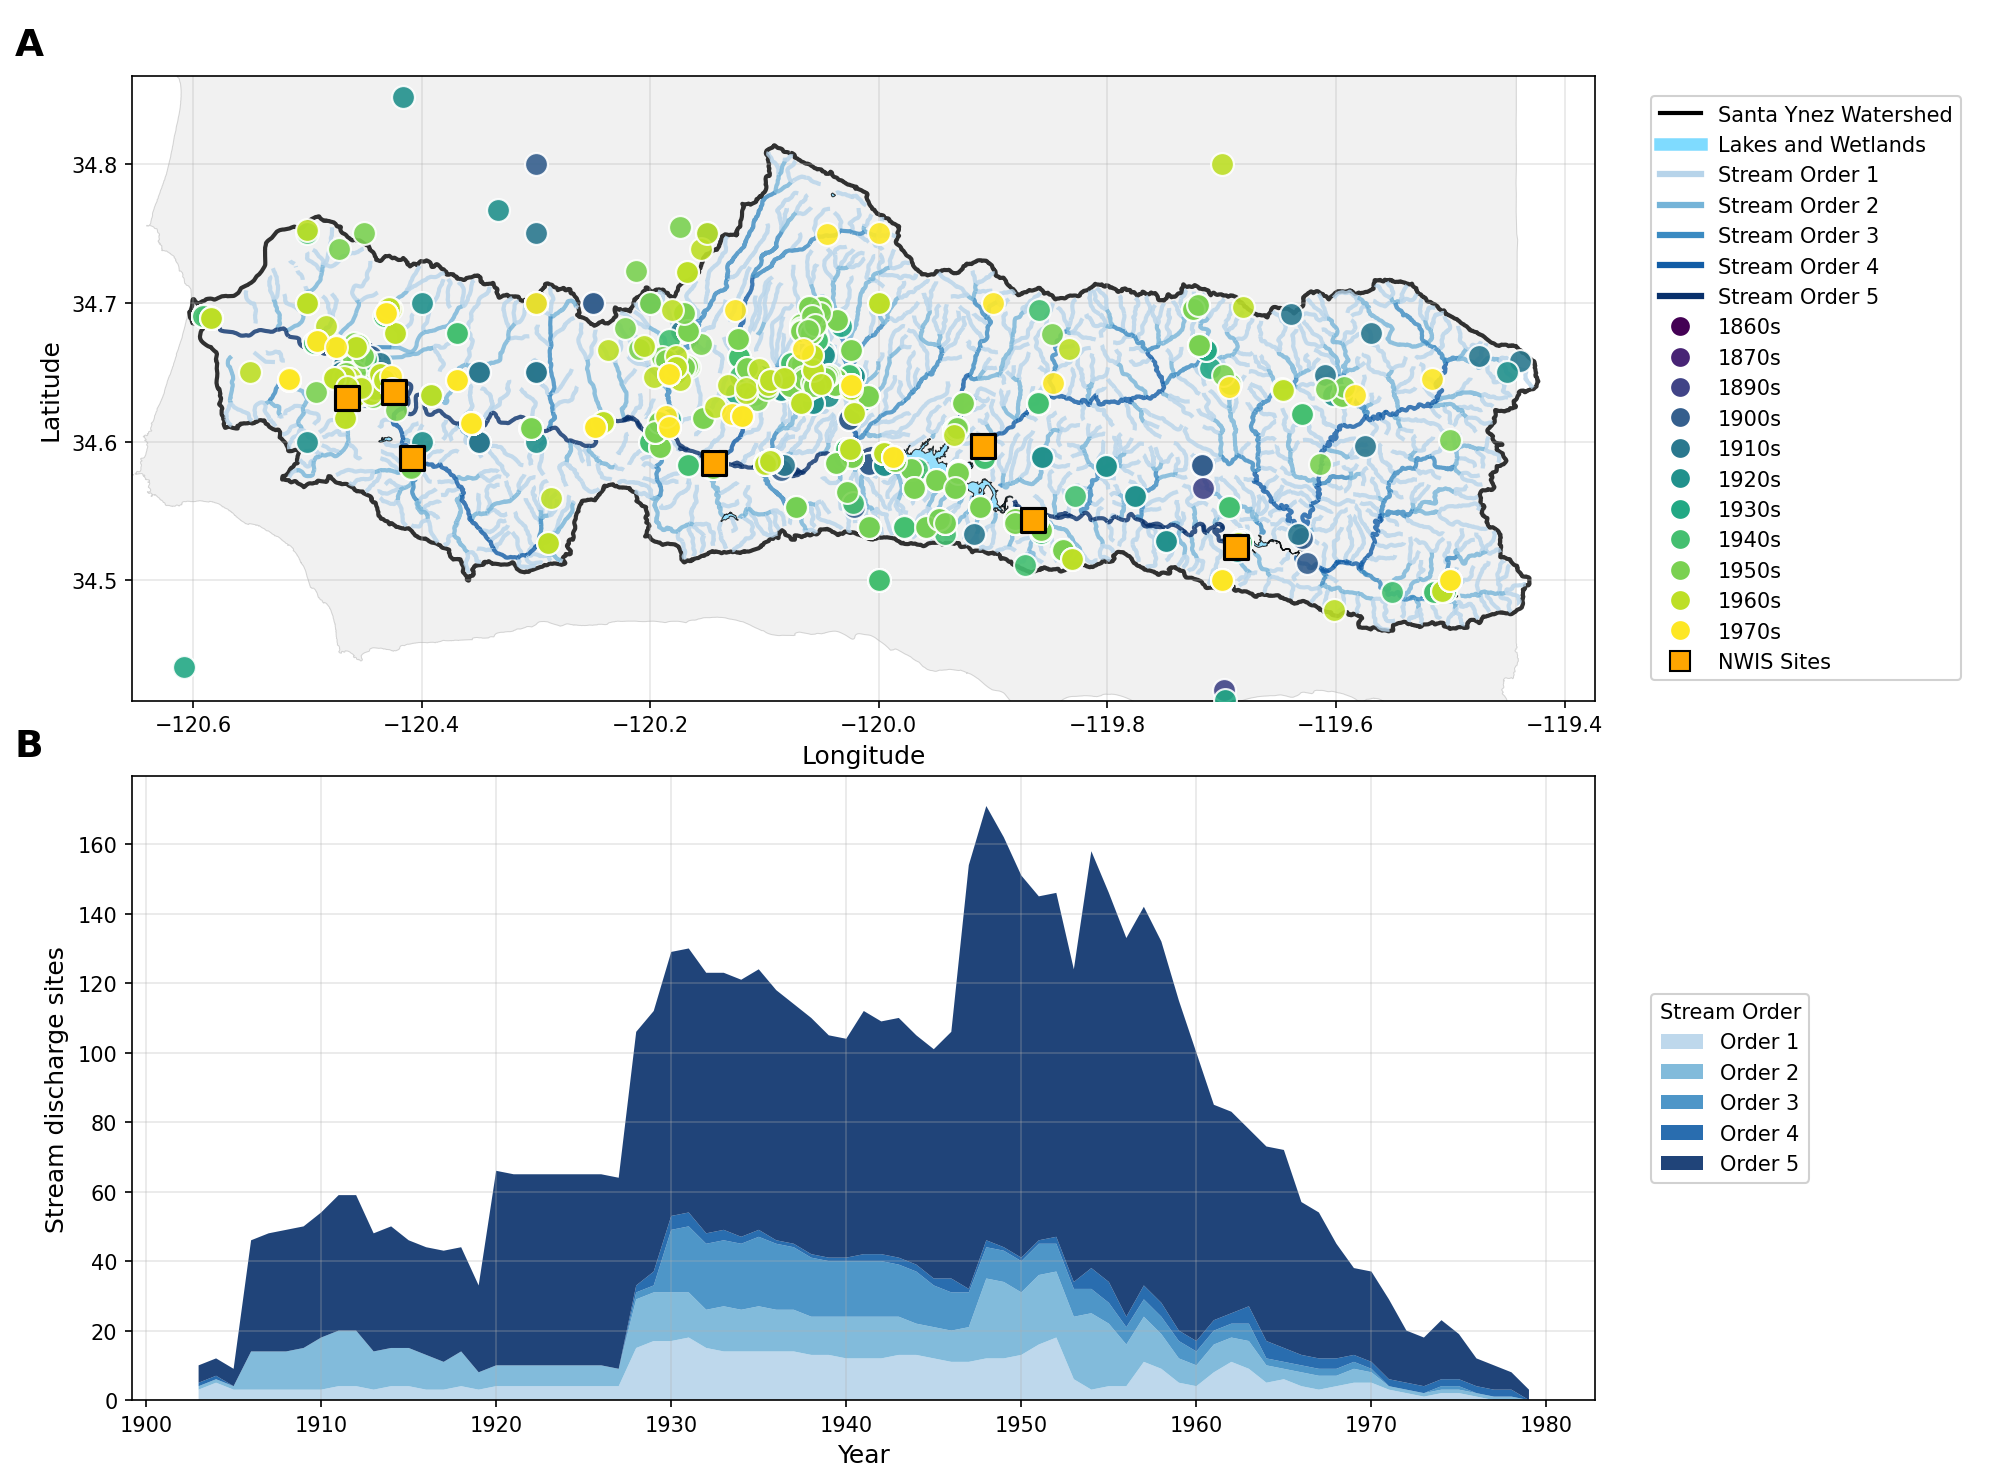

Saved santa_ynez_stream_order.png


In [9]:
# Decade colors for restored sites using viridis
decades_present = sorted(gdf_sy['decade_start'].dropna().unique().astype(int))
n_decades = len(decades_present)
viridis_colors = plt.cm.viridis(np.linspace(0, 1, max(n_decades, 1)))
decade_colors = {d: viridis_colors[i] for i, d in enumerate(decades_present)}

# Set up stream order colors (Blues 0.3–1.0, by index position)
stream_order_colors = {}
if rivers is not None and order_col:
    orders = sorted(rivers[order_col].dropna().unique())
    blues = plt.cm.Blues(np.linspace(0.3, 1.0, len(orders)))
    stream_order_colors = {o: blues[i] for i, o in enumerate(orders)}

fig = plt.figure(figsize=(16, 12), dpi=150)
gs = fig.add_gridspec(2, 2, width_ratios=[5, 1.2], height_ratios=[1.2, 1], hspace=0.02, wspace=0.05)

# -----------------------------------------------------------------------
# Panel A: Map (top left)
# -----------------------------------------------------------------------
ax_map = fig.add_subplot(gs[0, 0])

# SB county as light gray background
if sb_county is not None:
    sb_county.plot(ax=ax_map, color='lightgray', alpha=0.3, edgecolor='gray', linewidth=0.5)

# Watershed outline only (no fill)
watershed.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=2, alpha=0.8)

# Rivers colored by stream order
if rivers is not None and order_col and stream_order_colors:
    for o in sorted(stream_order_colors):
        r = rivers[rivers[order_col] == o]
        r.plot(ax=ax_map, color=stream_order_colors[o], linewidth=2, alpha=0.8, zorder=2)
elif rivers is not None:
    rivers.plot(ax=ax_map, color='#4a90d9', linewidth=1.5, alpha=0.8, zorder=2)

# Lakes clipped to watershed
if lakes is not None:
    lakes_clip = gpd.clip(lakes, watershed)
    if not lakes_clip.empty:
        lakes_clip.plot(ax=ax_map, color='#7FDBFF', edgecolor='black', linewidth=0.5, alpha=0.8, zorder=6)

# Restored sites colored by decade
for decade in decades_present:
    pts = gdf_sy[gdf_sy['decade_start'] == decade]
    if not pts.empty:
        ax_map.scatter(pts.geometry.x, pts.geometry.y,
                       c=[decade_colors[decade]], s=120, alpha=0.9,
                       edgecolors='white', linewidths=1, zorder=7)

# NWIS sites as orange squares
nwis_sy.plot(ax=ax_map, color='orange', markersize=140, marker='s',
             edgecolor='black', linewidth=1.5, zorder=9)

# Set extent from watershed bounds
minx, miny, maxx, maxy = watershed.total_bounds
buf = 0.05
ax_map.set_xlim(minx - buf, maxx + buf)
ax_map.set_ylim(miny - buf, maxy + buf)

ax_map.set_xlabel('Longitude', fontsize=12)
ax_map.set_ylabel('Latitude', fontsize=12)
ax_map.grid(True, alpha=0.3)
ax_map.text(-0.08, 1.02, 'A', transform=ax_map.transAxes,
            fontsize=18, fontweight='bold', ha='left', va='bottom', clip_on=False)

# -----------------------------------------------------------------------
# Map legend (top right)
# -----------------------------------------------------------------------
ax_map_legend = fig.add_subplot(gs[0, 1])
ax_map_legend.axis('off')

legend_elements = []
legend_elements.append(Line2D([0],[0], color='black', linewidth=2, label='Santa Ynez Watershed'))
if lakes is not None:
    lakes_clip_check = gpd.clip(lakes, watershed)
    if not lakes_clip_check.empty:
        legend_elements.append(Line2D([0],[0], color='#7FDBFF', linewidth=6, label='Lakes and Wetlands'))
if stream_order_colors:
    for o in sorted(stream_order_colors):
        legend_elements.append(Line2D([0],[0], color=stream_order_colors[o], linewidth=3,
                                      label=f'Stream Order {int(o)}'))
for d in decades_present:
    legend_elements.append(Line2D([0],[0], marker='o', color='w',
                                  markerfacecolor=decade_colors[d], markeredgecolor='white',
                                  markersize=10, label=f'{d}s'))
legend_elements.append(Line2D([0],[0], marker='s', color='w',
                               markerfacecolor='orange', markeredgecolor='black',
                               markersize=10, label='NWIS Sites'))
ax_map_legend.legend(handles=legend_elements, loc='center left',
                     bbox_to_anchor=(0, 0.5), framealpha=0.9, fontsize=10)

# -----------------------------------------------------------------------
# Panel B: Timeline (bottom left)
# -----------------------------------------------------------------------
ax_time = fig.add_subplot(gs[1, 0])

if 'stream_order' in gdf_sy_order.columns:
    so = gdf_sy_order.copy()
    so['year_start'] = pd.to_numeric(so['year_start'], errors='coerce')
    so['year_end']   = pd.to_numeric(so['year_end'],   errors='coerce')
    so['so_int']     = pd.to_numeric(so['stream_order'], errors='coerce')
    so = so.dropna(subset=['year_start', 'year_end', 'so_int'])
    so['year_start'] = so['year_start'].astype(int)
    so['year_end']   = so['year_end'].astype(int)
    so['so_int']     = so['so_int'].astype(int)

    counts = defaultdict(int)
    for _, row in so.iterrows():
        ys, ye, o = row['year_start'], row['year_end'], row['so_int']
        if ys > ye: ys, ye = ye, ys
        for y in range(ys, ye + 1):
            counts[(y, o)] += 1

    if counts:
        idx = pd.MultiIndex.from_tuples(counts.keys(), names=['year','stream_order'])
        pvt_t = (pd.Series(counts, index=idx).sort_index()
                 .rename('count').reset_index()
                 .pivot(index='year', columns='stream_order', values='count')
                 .fillna(0).astype(int))
        orders_r = sorted(pvt_t.columns.tolist())
        cols = [stream_order_colors.get(o, 'steelblue') for o in orders_r]
        ax_time.stackplot(pvt_t.index,
                          [pvt_t[o].values for o in orders_r],
                          labels=[f'Order {int(o)}' for o in orders_r],
                          colors=cols, alpha=0.9)
    else:
        pvt_t = None
else:
    pvt_t = None
    gdf_sy['year_start'] = pd.to_numeric(gdf_sy['year_start'], errors='coerce')
    year_counts = gdf_sy.groupby('year_start').size()
    ax_time.bar(year_counts.index.astype(int), year_counts.values, color='steelblue', width=1.0)

ax_time.set_xlabel('Year', fontsize=12)
ax_time.set_ylabel('Stream discharge sites', fontsize=12)
ax_time.grid(True, alpha=0.3)
ax_time.text(-0.08, 1.02, 'B', transform=ax_time.transAxes,
             fontsize=18, fontweight='bold', ha='left', va='bottom', clip_on=False)

# -----------------------------------------------------------------------
# Timeline legend (bottom right)
# -----------------------------------------------------------------------
ax_time_legend = fig.add_subplot(gs[1, 1])
ax_time_legend.axis('off')
if pvt_t is not None and stream_order_colors:
    legend_elements_t = [
        mpatches.Patch(facecolor=stream_order_colors.get(o, 'steelblue'), alpha=0.9,
                       label=f'Order {int(o)}')
        for o in sorted(pvt_t.columns.tolist())
    ]
    ax_time_legend.legend(handles=legend_elements_t, title='Stream Order',
                          loc='center left', bbox_to_anchor=(0, 0.5),
                          framealpha=0.9, fontsize=10)

plt.savefig(figures_path / 'santa_ynez_stream_order.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved santa_ynez_stream_order.png')